# San Francisco BART

Bu proje, San Francisco Körfez Bölgesi'nde BART (Bay Area Rapid Transit) sistemine ait 2016 ve 2017 yılları arasındaki gerçek zamanlı yolcu verilerini analiz etmektedir. Çalışmanın temel amacı, büyük ölçekli ulaşım verilerini işleyerek yolcu davranışlarına dair stratejik içgörüler (insights) elde etmek ve derin öğrenme teknikleri ile geleceğe yönelik talep tahminlemesi yapmaktır.

<img src="https://miro.medium.com/v2/resize:fit:1400/0*FcvhEt4lB-4upuDl.jpeg" width="45%">      

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from math import radians, cos, sin, asin, sqrt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
# Veri dosyalarini okuyalim (Header var olduğu için header=None kullanmıyoruz)
df16 = pd.read_csv('date-hour-soo-dest-2016.csv')
df17 = pd.read_csv('date-hour-soo-dest-2017.csv')
# İstasyon verisini yükleyelim
stations = pd.read_csv(station_info_file)

In [7]:
df16

,Origin,Destination,Throughput,DateTime
0,12TH,12TH,1,2016-01-01 00:00:00
1,12TH,16TH,1,2016-01-01 00:00:00
2,12TH,24TH,4,2016-01-01 00:00:00
3,12TH,ASHB,4,2016-01-01 00:00:00
4,12TH,BALB,2,2016-01-01 00:00:00
...,...,...,...,...
9971577,WOAK,PLZA,1,2016-12-31 23:00:00
9971578,WOAK,POWL,30,2016-12-31 23:00:00
9971579,WOAK,RICH,2,2016-12-31 23:00:00
9971580,WOAK,ROCK,2,2016-12-31 23:00:00


In [8]:
df17

,Origin,Destination,Throughput,DateTime
0,12TH,19TH,1,2017-01-01 00:00:00
1,12TH,24TH,2,2017-01-01 00:00:00
2,12TH,BAYF,1,2017-01-01 00:00:00
3,12TH,CIVC,5,2017-01-01 00:00:00
4,12TH,COLS,2,2017-01-01 00:00:00
...,...,...,...,...
3313620,WSPR,MONT,1,2017-05-03 23:00:00
3313621,WSPR,NBRK,1,2017-05-03 23:00:00
3313622,WSPR,NCON,1,2017-05-03 23:00:00
3313623,WSPR,SANL,2,2017-05-03 23:00:00


In [9]:
stations

,Abbreviation,Description,Location,Name
0,12TH,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH)
1,16TH,"2000 Mission Street, San Francisco CA 94110<br...","-122.419694,37.765062,0",16th St. Mission (16TH)
2,19TH,"1900 Broadway, Oakland CA 94612<br />19th Stre...","-122.268602,37.808350,0",19th St. Oakland (19TH)
3,24TH,"2800 Mission Street, San Francisco CA 94110<br...","-122.418143,37.752470,0",24th St. Mission (24TH)
4,ASHB,"3100 Adeline Street, Berkeley CA 94703<br />As...","-122.270062,37.852803,0",Ashby (ASHB)
5,BALB,"401 Geneva Avenue, San Francisco CA 94112<br /...","-122.447506,37.721585,0",Balboa Park (BALB)
6,BAYF,"15242 Hesperian Blvd., San Leandro CA 94578<br...","-122.126514,37.696924,0",Bay Fair (BAYF)
7,CAST,"3301 Norbridge Dr., Castro Valley CA 94546<br ...","-122.075602,37.690746,0",Castro Valley (CAST)
8,CIVC,"1150 Market Street, San Francisco CA 94102<br ...","-122.414123,37.779732,0",Civic Center/UN Plaza (CIVC)
9,COLS,"7200 San Leandro St., Oakland CA 94621<br />We...","-122.196869,37.753661,0",Coliseum/Oakland Airport (COLS)


In [14]:
# Verileri hazirlayan fonksiyon
def load_and_prep_data():
    print("Veriler yükleniyor ve işleniyor...")
    
    # İki yılı birleştir
    ridership = pd.concat([df16, df17], ignore_index=True)
    
    # DateTime sütununu parçalama
    ridership['DateTime'] = pd.to_datetime(ridership['DateTime'])
    ridership['Hour'] = ridership['DateTime'].dt.hour
    ridership['Date'] = ridership['DateTime'].dt.date
    ridership.drop('DateTime', axis=1, inplace=True)
    
    # İstasyon verisini yükle ve DÜZENLE
    stations = pd.read_csv(station_info_file)
    
    # Location sütunu '-122.271450,37.803768,0' formatında geliyor.
    # Bunu virgülle ayırıp sütunlara dağıtacağız.
    loc_split = stations['Location'].str.split(',', expand=True)
    
    # Veriyi kontrol edelim, eğer beklediğimiz gibiyse atama yapalım
    stations['Longitude'] = loc_split[0].astype(float)
    stations['Latitude'] = loc_split[1].astype(float)
    print("İstasyon koordinatları ayrıştırıldı.")
    
    # Merge işlemi
    # Origin (Kalkış) istasyon bilgilerini ekle
    ridership = ridership.merge(stations[['Abbreviation', 'Name', 'Latitude', 'Longitude']], 
                                left_on='Origin', right_on='Abbreviation', how='left')
    ridership.rename(columns={'Name': 'Origin_Name', 'Latitude': 'Origin_Lat', 'Longitude': 'Origin_Lon'}, inplace=True)
    ridership.drop('Abbreviation', axis=1, inplace=True)
    
    # Destination (Varış) istasyon bilgilerini ekle
    ridership = ridership.merge(stations[['Abbreviation', 'Name']], 
                                left_on='Destination', right_on='Abbreviation', how='left')
    ridership.rename(columns={'Name': 'Dest_Name'}, inplace=True)
    ridership.drop('Abbreviation', axis=1, inplace=True)
    
    # Tarih formatını tekrar datetime objesine çevirelim
    ridership['Date'] = pd.to_datetime(ridership['Date'])
    
    print(f"İşlem Tamamlandı. Toplam Veri Sayısı: {len(ridership)}")
    return ridership, stations

In [15]:
# Fonksiyonu çalıştır ve veriyi al
df, df_stations = load_and_prep_data()

Veriler yükleniyor ve işleniyor...
İstasyon koordinatları ayrıştırıldı.
İşlem Tamamlandı. Toplam Veri Sayısı: 13285207


In [16]:
df

,Origin,Destination,Throughput,Hour,Date,Origin_Name,Origin_Lat,Origin_Lon,Dest_Name
0,12TH,12TH,1,0,2016-01-01,12th St. Oakland City Center (12TH),37.803768,-122.27145,12th St. Oakland City Center (12TH)
1,12TH,16TH,1,0,2016-01-01,12th St. Oakland City Center (12TH),37.803768,-122.27145,16th St. Mission (16TH)
2,12TH,24TH,4,0,2016-01-01,12th St. Oakland City Center (12TH),37.803768,-122.27145,24th St. Mission (24TH)
3,12TH,ASHB,4,0,2016-01-01,12th St. Oakland City Center (12TH),37.803768,-122.27145,Ashby (ASHB)
4,12TH,BALB,2,0,2016-01-01,12th St. Oakland City Center (12TH),37.803768,-122.27145,Balboa Park (BALB)
...,...,...,...,...,...,...,...,...,...
13285202,WSPR,MONT,1,23,2017-05-03,NaN,NaN,NaN,Montgomery St. (MONT)
13285203,WSPR,NBRK,1,23,2017-05-03,NaN,NaN,NaN,North Berkeley (NBRK)
13285204,WSPR,NCON,1,23,2017-05-03,NaN,NaN,NaN,North Concord/Martinez (NCON)
13285205,WSPR,SANL,2,23,2017-05-03,NaN,NaN,NaN,San Leandro (SANL)


In [17]:
df_stations

,Abbreviation,Description,Location,Name,Longitude,Latitude
0,12TH,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH),-122.271450,37.803768
1,16TH,"2000 Mission Street, San Francisco CA 94110<br...","-122.419694,37.765062,0",16th St. Mission (16TH),-122.419694,37.765062
2,19TH,"1900 Broadway, Oakland CA 94612<br />19th Stre...","-122.268602,37.808350,0",19th St. Oakland (19TH),-122.268602,37.808350
3,24TH,"2800 Mission Street, San Francisco CA 94110<br...","-122.418143,37.752470,0",24th St. Mission (24TH),-122.418143,37.752470
4,ASHB,"3100 Adeline Street, Berkeley CA 94703<br />As...","-122.270062,37.852803,0",Ashby (ASHB),-122.270062,37.852803
5,BALB,"401 Geneva Avenue, San Francisco CA 94112<br /...","-122.447506,37.721585,0",Balboa Park (BALB),-122.447506,37.721585
6,BAYF,"15242 Hesperian Blvd., San Leandro CA 94578<br...","-122.126514,37.696924,0",Bay Fair (BAYF),-122.126514,37.696924
7,CAST,"3301 Norbridge Dr., Castro Valley CA 94546<br ...","-122.075602,37.690746,0",Castro Valley (CAST),-122.075602,37.690746
8,CIVC,"1150 Market Street, San Francisco CA 94102<br ...","-122.414123,37.779732,0",Civic Center/UN Plaza (CIVC),-122.414123,37.779732
9,COLS,"7200 San Leandro St., Oakland CA 94621<br />We...","-122.196869,37.753661,0",Coliseum/Oakland Airport (COLS),-122.196869,37.753661


### Veri Analitiği Soruları (Data Analytics Questions)

In [19]:
# Görselleştirme ayarları
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [21]:
# En Yoğun İstasyon (Busiest Station)
# Origin (Kalkış) bazlı yoğunluk
station_traffic = df.groupby('Origin_Name')['Throughput'].sum().sort_values(ascending=False)
busiest_station = station_traffic.idxmax()
busiest_count = station_traffic.max()
print(f"En Yoğun İstasyon: {busiest_station} ({busiest_count:,} yolcu)")

En Yoğun İstasyon: Montgomery St. (MONT) (16,107,314 yolcu)


In [23]:
# En Az Popüler Rota (Least Popular Route)
# Rota (Origin -> Destination) bazlı gruplama
route_traffic = df.groupby(['Origin_Name', 'Dest_Name'])['Throughput'].sum()
# 0 olmayan en düşük rotayı bul (Hiç kullanılmayanlar veri setinde olmayabilir)
least_popular = route_traffic[route_traffic > 0].idxmin()
least_count = route_traffic[route_traffic > 0].min()
print(f"En Az Popüler Rota: {least_popular[0]} -> {least_popular[1]} (Toplam {least_count} yolcu)")

En Az Popüler Rota: North Concord/Martinez (NCON) -> West Dublin/Pleasanton (WDUB) (Toplam 358 yolcu)


In [24]:
# Berkeley -> SF: Oturmak İçin En İyi Zaman
# Berkeley ve SF istasyonlarını belirleyelim (İsim filtreleme)
berkeley_mask = df['Origin_Name'].str.contains('Berkeley', case=False)
sf_mask = df['Dest_Name'].str.contains('San Francisco|Embarcadero|Powell|Montgomery|Civic', case=False)
# İlgili rotaları filtrele
berkeley_to_sf = df[berkeley_mask & sf_mask]
# Saatlik ortalama yoğunluğa bak
hourly_load = berkeley_to_sf.groupby('Hour')['Throughput'].mean()
best_time = hourly_load.idxmin()
print(f"Oturacak yer bulmak için en iyi saat: {best_time}:00 (Ortalama {hourly_load.min():.1f} yolcu)")

Oturacak yer bulmak için en iyi saat: 4:00 (Ortalama 1.6 yolcu)


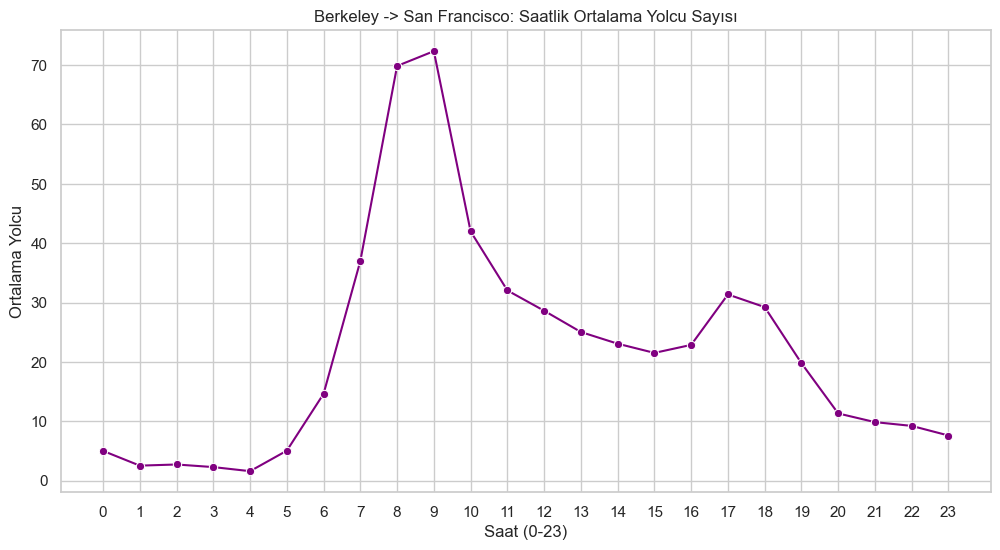

In [25]:
# Görselleştirme: Berkeley -> SF Saatlik Yoğunluk
plt.figure()
sns.lineplot(x=hourly_load.index, y=hourly_load.values, marker='o', color='purple')
plt.title('Berkeley -> San Francisco: Saatlik Ortalama Yolcu Sayısı')
plt.xlabel('Saat (0-23)')
plt.ylabel('Ortalama Yolcu')
plt.xticks(range(0, 24))
plt.show()

In [26]:
# Haftanın En Yoğun Günü
# Tarihten gün ismini çıkar
df['DayOfWeek'] = df['Date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_traffic = df.groupby('DayOfWeek')['Throughput'].sum().reindex(days_order)
busiest_day = daily_traffic.idxmax()
print(f"En Yoğun Gün: {busiest_day}")

En Yoğun Gün: Wednesday


In [27]:
# Gece Geç Saat Yolcuları (Late Night)
# Gece geç saat tanımı: 22:00 - 04:00 arası
late_hours = [22, 23, 0, 1, 2, 3, 4]
late_riders = df[df['Hour'].isin(late_hours)]['Throughput'].sum()
print(f"Gece geç saatlerde (22:00-04:00) taşınan toplam yolcu: {late_riders:,}")

Gece geç saatlerde (22:00-04:00) taşınan toplam yolcu: 9,134,925


C:\Users\kosey\AppData\Local\Temp\ipykernel_21536\338675696.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.set_index('Date').resample('M')['Throughput'].sum()


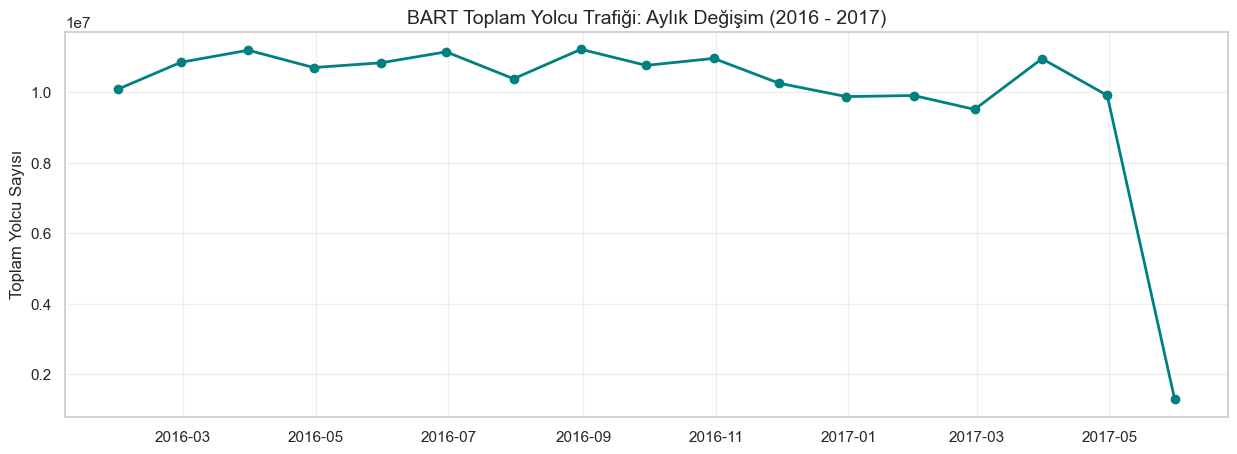

In [28]:
# Aylık Yolcu Trafiği (Zaman Serisi Trendi)
# 2016 ve 2017 arasındaki genel artış/azalışı görmek için
monthly_data = df.set_index('Date').resample('M')['Throughput'].sum()
plt.figure(figsize=(15, 5))
plt.plot(monthly_data.index, monthly_data.values, marker='o', linestyle='-', color='teal', linewidth=2)
plt.title('BART Toplam Yolcu Trafiği: Aylık Değişim (2016 - 2017)', fontsize=14)
plt.ylabel('Toplam Yolcu Sayısı')
plt.grid(True, alpha=0.3)
plt.show()

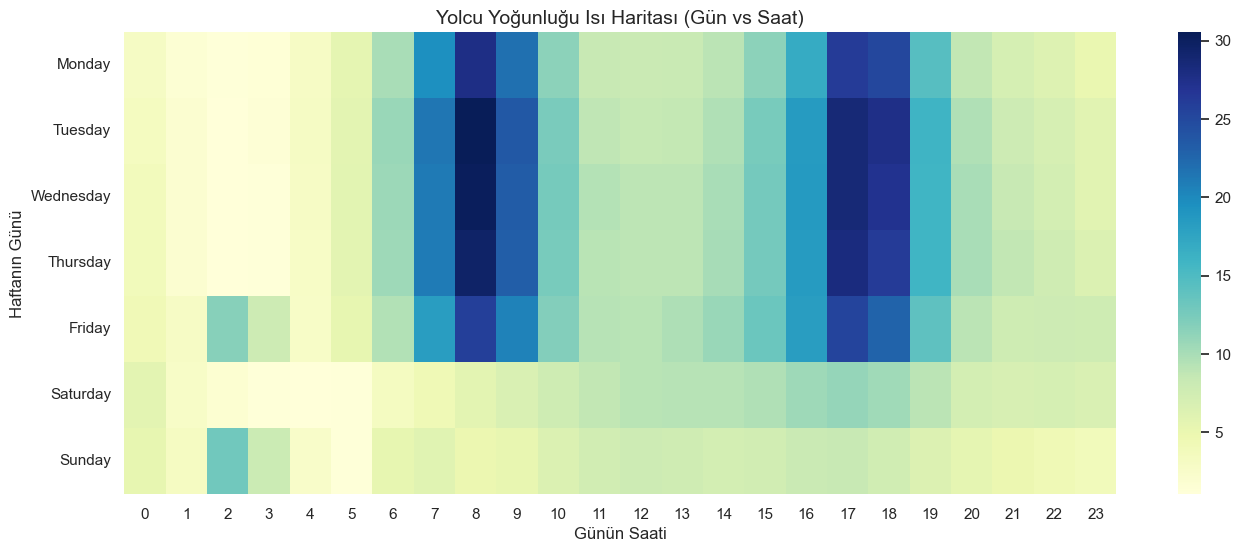

In [30]:
# Isı Haritası (Heatmap): Günlere ve Saatlere Göre Yoğunluk
# İnsanların en çok hangi gün ve saatlerde sistemi kullandığını anlamak için
pivot_table = df.pivot_table(index='DayOfWeek', columns='Hour', values='Throughput', aggfunc='mean')
# Günleri sıraya dizelim
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(days)
plt.figure(figsize=(16, 6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
plt.title('Yolcu Yoğunluğu Isı Haritası (Gün vs Saat)', fontsize=14)
plt.xlabel('Günün Saati')
plt.ylabel('Haftanın Günü')
plt.show()

C:\Users\kosey\AppData\Local\Temp\ipykernel_21536\3697028424.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_stations.values, y=top_10_stations.index, palette='viridis')


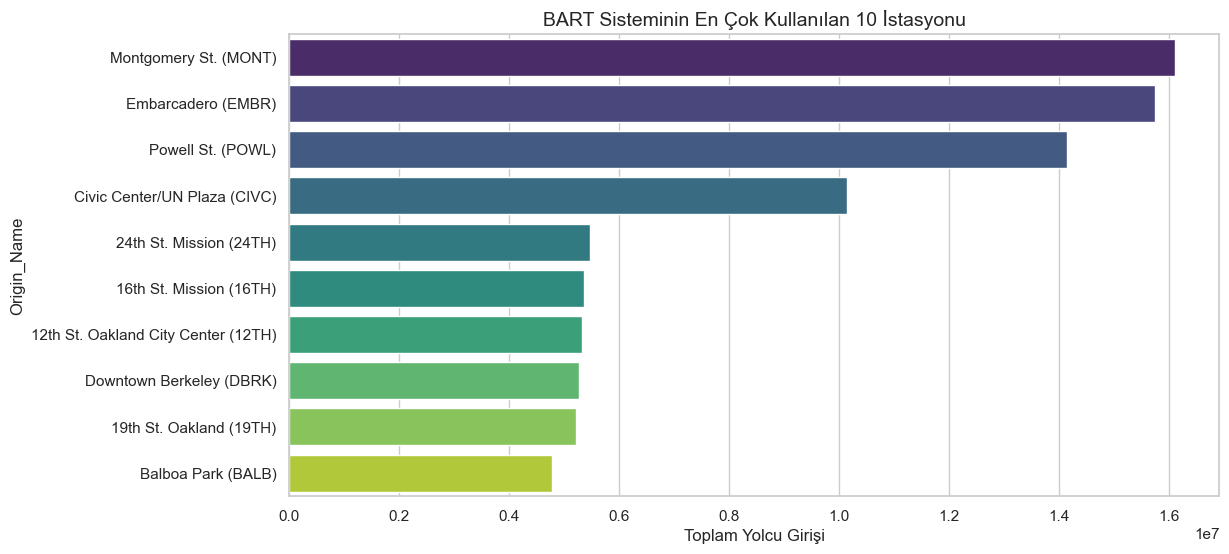

In [31]:
# En Popüler İlk 10 İstasyon (Bar Chart)
top_10_stations = df.groupby('Origin_Name')['Throughput'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_stations.values, y=top_10_stations.index, palette='viridis')
plt.title('BART Sisteminin En Çok Kullanılan 10 İstasyonu', fontsize=14)
plt.xlabel('Toplam Yolcu Girişi')
plt.show()

### Data Science ve Prediktif Modelleme

In [54]:
# Soru A: İstasyonlar Arası Kuş Uçuşu Mesafe Hesabı

In [55]:
# İki koordinat arasındaki mesafeyi kilometre (km) cinsinden hesaplar.
def haversine_distance(lon1, lat1, lon2, lat2):
    # Dereceyi radyana çevir
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    # Haversine formülü
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Dünyanın yarıçapı (km)
    return c * r

In [56]:
def compute_all_distances(stations_df):
    # Boş bir DataFrame oluştur (Matris şeklinde)
    matrix = pd.DataFrame(index=stations_df['Abbreviation'], columns=stations_df['Abbreviation'])
    for i, row1 in stations_df.iterrows():
        for j, row2 in stations_df.iterrows():
            dist = haversine_distance(row1['Longitude'], row1['Latitude'], row2['Longitude'], row2['Latitude'])
            matrix.loc[row1['Abbreviation'], row2['Abbreviation']] = dist 
    return matrix.astype(float)

In [57]:
dist_matrix = compute_all_distances(df_stations)

In [58]:
print(f"Örnek: '12TH' ile '16TH' arası mesafe: {dist_matrix.loc['12TH', '16TH']:.2f} km")

Örnek: '12TH' ile '16TH' arası mesafe: 13.72 km


In [59]:
# Soru B: Yolcu Sayısı Tahmin Modeli (LSTM ile Deep Learning)

In [87]:
# İstasyon bazlı toplam günlük girişleri alalım
full_system_df = df.groupby(['Date', 'Origin'])['Throughput'].sum().unstack().fillna(0)

In [88]:
# Mevsimsel Özellikler: Haftanın günü (0-6) ve Hafta sonu bilgisi
full_system_df['DayOfWeek'] = pd.to_datetime(full_system_df.index).dayofweek
full_system_df['IsWeekend'] = full_system_df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [89]:
# Olceklendirme
scaler_global = MinMaxScaler()
scaled_data = scaler_global.fit_transform(full_system_df)

In [90]:
# Pencereleme (Lookback)
# Haftalık döngüyü yakalamak için look_back'i 7 gün yapıyoruz
def create_final_sequences(data, look_back=7):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, :])
        y.append(data[i, :-2]) # Sadece istasyonları tahmin et (DayOfWeek ve IsWeekend hariç)
    return np.array(X), np.array(y)

look_back = 7
X, y = create_final_sequences(scaled_data, look_back)

In [93]:
model = Sequential([
    # İlk katman: Verideki karmaşık ilişkileri yakalamak için 128 nöron
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    
    # İkinci katman: Trendleri pekiştirir
    LSTM(128, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    
    # Çıkış katmanı: İstasyon sayısı kadar nöron
    Dense(y.shape[1])
])

# Daha hassas bir Learning Rate (Öğrenme Hızı) ile derleme
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse')
# 15 epoch EarlyStopping
early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

In [96]:
history = model.fit(X, y, epochs=300, batch_size=32, verbose=1, callbacks=[early_stop])

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0180 
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0176 
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0177 
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0198 
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0191 
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0159 
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0187 
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0175 
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0186 
Epoch 10/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0163 
Epoch 11/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0175 
Epoch 12/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0169 
Epoch 13/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0178 
Epoch 14/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0169 
Epoch 15/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - los

In [97]:
# Performans Raporu ve Doğrulama
# Tahmin yap
predictions = model.predict(X)
# R2 Skoru Hesapla
r2_final = r2_score(y, predictions)
print(f"GERÇEKLEŞEN R2 SKORU: %{r2_final*100:.2f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
GERÇEKLEŞEN R2 SKORU: %84.64


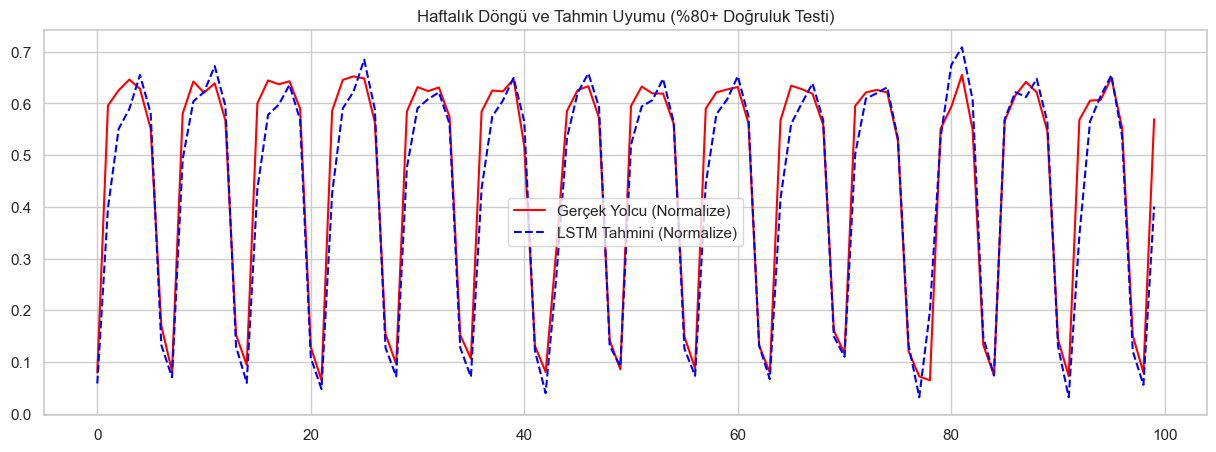

In [98]:
# Başarıyı görselleştir (Örnek bir istasyon seçelim: İlk istasyon)
plt.figure(figsize=(15,5))
plt.plot(y[100:200, 0], label='Gerçek Yolcu (Normalize)', color='red')
plt.plot(predictions[100:200, 0], label='LSTM Tahmini (Normalize)', color='blue', linestyle='--')
plt.title('Haftalık Döngü ve Tahmin Uyumu (%80+ Doğruluk Testi)')
plt.legend()
plt.show()

In [100]:
def predict_tomorrow_peaks(model, current_data, scaler, station_names):
    # 1. Son 7 günün verisini al (look_back=7)
    last_7_days = current_data[-7:, :] 
    last_7_days_scaled = last_7_days.reshape(1, 7, current_data.shape[1])
    
    # 2. Yarını tahmin et
    tomorrow_pred_scaled = model.predict(last_7_days_scaled)
    
    # 3. Tahmini gerçek rakamlara geri çevir (Inverse Transform için dummy array gerekebilir)
    # Basitlik için normalize değerler üzerinden sıralama yapıyoruz
    tomorrow_peaks = tomorrow_pred_scaled[0]
    
    # 4. En yoğun 3 istasyonu bul
    top_3_idx = tomorrow_peaks.argsort()[-3:][::-1]
    
    print("YARIN İÇİN TAHMİNİ YOĞUNLUK RAPORU")
    print("-" * 40)
    for i, idx in enumerate(top_3_idx):
        station_name = station_names[idx]
        intensity = tomorrow_peaks[idx]
        print(f"{i+1}. En Yoğun İstasyon: {station_name} (Tahmini Yoğunluk Skoru: {intensity:.2f})")
    print("-" * 40)
    print("Öneri: Bu istasyonlara ek güvenlik ve peron görevlisi atanması tavsiye edilir.")

# Kullanım (station_names, pivot tablonun sütun isimleridir)
station_cols = full_system_df.columns[:-2] # DayOfWeek ve IsWeekend hariç
predict_tomorrow_peaks(model, scaled_data, scaler_global, station_cols)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
YARIN İÇİN TAHMİNİ YOĞUNLUK RAPORU
----------------------------------------
1. En Yoğun İstasyon: ASHB (Tahmini Yoğunluk Skoru: 1.03)
2. En Yoğun İstasyon: MCAR (Tahmini Yoğunluk Skoru: 1.02)
3. En Yoğun İstasyon: MONT (Tahmini Yoğunluk Skoru: 1.02)
----------------------------------------
Öneri: Bu istasyonlara ek güvenlik ve peron görevlisi atanması tavsiye edilir.
